# Plot figures analogue analysis (poster/presentation)

### Packages and Directories

In [6]:
# --- Imports ---
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import dask
from dask.distributed import Client, LocalCluster
from scipy.interpolate import griddata
from statsmodels.stats.multitest import fdrcorrection
import calendar
from datetime import datetime, timedelta
import cftime

from scipy import ndimage

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Custom Functions ---
# sys.path.append('/home/portal/script/python/precip_Cristina/')                    # tintin
sys.path.append('/home/alice/Desktop/work/git/myISACcode/python/precip_Cristina')   # alice
import functions_analogues_PrMax as fanPM
import functions_analogues_LUCAFAMOSS as fan

In [7]:
# Define directories for data and figures
# # tintin
# CERRA_dir = '/work_big/users/clima/portal/CERRA/'
# ERA5_dir = '/work_big/users/clima/portal/ERA5/'
# CRCM5_dir = '/work_big/users/clima/portal/CRCM5-LE/'
# fig_dir = '/home/portal/figures/analogues/'

# alice
CERRA_dir = '/media/alice/Crucial X9/portal/data_CNR/CERRA/'
ERA5_dir = '/media/alice/Crucial X9/portal/data_CNR/ERA5/'
CRCM5_dir = '/media/alice/Crucial X9/portal/data_CNR/CRCM5-LE/'
fig_dir = '/home/alice/Desktop/CNR/ENCIRCLE/materiale_alice/figures/analogues/poster/'
diff_dir = './analogue_data/analogue_differences/'
pr_mask_dir = './analogue_data/pr_in_mask/'

### Parameters

In [28]:
# Variable
var_analogues = 'psl-std'  # Variable used to find the analogues, e.g. 'psl' for sea level pressure
var_BAM = 'psl'                  # Variable used for the BAM search

# Quantile and analogue number
qtl_LE = 0.99
no_analogues = 18

# Number of ensemble members
no_membs = 49

# List of members
list_membs = [name for name in os.listdir(CRCM5_dir + 'psl') if os.path.isdir(os.path.join(CRCM5_dir + 'psl', name))]
list_membs = sorted(list_membs)[:no_membs]  # Select the first 'no_membs' members


#### Average precipitation in BAM >20mm mask for all events

In [29]:
# Parameters
# Variable
varname = 'pr'
factor = 3600

# List events
list_nodes = [1,3,5,5,6]
list_events = [1,3,4,23,19]
tot_events = len(list_nodes)

# List epochs
list_year_ranges = [[1955, 1974], [2004, 2023], [2080, 2099]] # past [1955-1974], present [2004-2023], near-future [2030-2049], far future [2080-2099]
no_epochs = len(list_year_ranges)

# List of ensemble sizes (by no members considered)
no_membs = 49

In [30]:
# Initialise empty lists for statistics
list_stats_past = []  # List to store statistics for past epochs
list_stats_future = []  # List to store statistics for future epochs
list_ds_reg = []  # List to store difference datasets


for ie in range(tot_events):
    no_node = list_nodes[ie]
    no_event = list_events[ie]
    # BAM regional mean precipitation
    BAM_info, BAM_index = fanPM.get_best_model_analogue_info(no_node, no_event, var_BAM)
    mean_pr_BAM_in_mask = BAM_info['precip_in_BAM_20mm_mask'][BAM_index]
    str_event_BAM = f'BAM-node{no_node}-extreme{no_event}-alertregions'

    # Upload analogue data for mean precipitation in BAM mask
    for j in range(no_epochs):
        year_range = list_year_ranges[j]
        str_year_range = "-".join(str(x) for x in year_range)

        # Load analogue values
        pr_reg_epoch = None
        for im, memb in enumerate(list_membs[:no_membs]):
            file = f'{pr_mask_dir}analogues-{var_analogues}_mask-mean-{varname}_{str_event_BAM}_{int(100*qtl_LE)}pct_{str_year_range}_CRCM5_{memb}.nc'
            if not os.path.exists(file):
                print(f'File {file} does not exist. Skipping epoch {j+1}.')
                continue
            pr_reg = xr.open_dataset(file)['pr'].values
            if pr_reg_epoch is None:
                pr_reg_epoch = pr_reg
            else:
                pr_reg_epoch = np.concatenate((pr_reg_epoch, pr_reg))
        list_ds_reg.append(np.array(pr_reg_epoch))

    # Compute p-val using KS test
    arr_past = list_ds_reg[-3].flatten()
    arr_past = arr_past[~np.isnan(arr_past)]
    arr_present = list_ds_reg[-2].flatten()
    arr_present = arr_present[~np.isnan(arr_present)]
    arr_future = list_ds_reg[-1].flatten()
    arr_future = arr_future[~np.isnan(arr_future)]
    list_stats_past.append(fanPM.ks_stat_and_pval(arr_past, arr_present))
    list_stats_future.append(fanPM.ks_stat_and_pval(arr_present, arr_future))

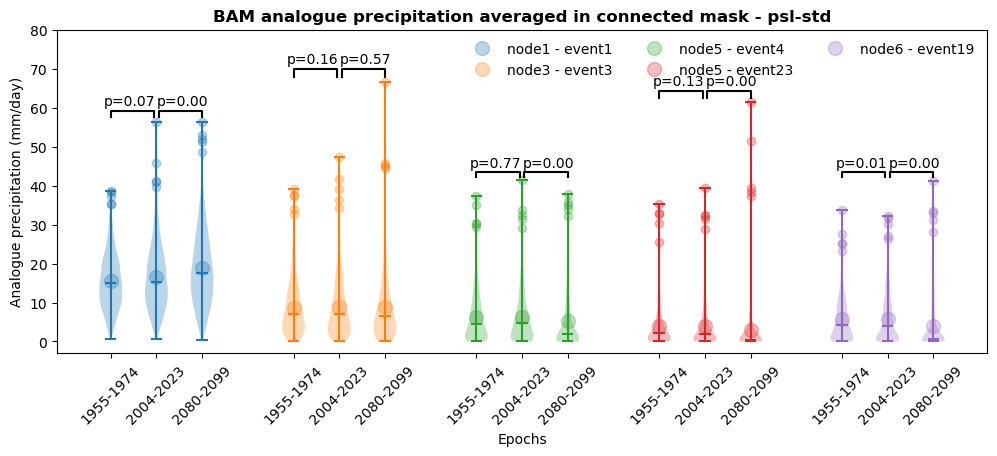

In [32]:
# Plot violin plots per epoch, once per ensemble size

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 4.2))
ax.set_title(f"BAM analogue precipitation averaged in connected mask - {var_analogues}", fontsize=12, weight="bold")

# Violin plot setup
list_epoch_str = [f"{year_range[0]}-{year_range[1]}" for year_range in list_year_ranges]

for i in range(tot_events):
    # Get the data for the current epoch and ensemble size
    list_reg_precip = list_ds_reg[i*no_epochs:(i+1)*no_epochs]
    # Plot the violin for the current epoch and ensemble size
    reg_precip_clean = [x[~np.isnan(x)]*factor for x in list_reg_precip]
    violin = ax.violinplot(reg_precip_clean, positions=1+i*4+np.arange(no_epochs),showmeans=False, showmedians=True, showextrema=True)
    # Plot the mean precipitation for the epoch
    violin_color = violin['bodies'][0].get_facecolor().flatten()
    plot_label = f'node{list_nodes[i]} - event{list_events[i]}'
    ax.plot(1+i*4+np.arange(no_epochs), [np.mean(reg_precip_clean[j]) for j in range(len(reg_precip_clean))], marker='o', color=violin_color, markersize=10, label=plot_label, linewidth=0)
    # Plot the 5 top values as stars
    for j in range(no_epochs):
        top5_values = np.sort(reg_precip_clean[j])[-5:]
        ax.plot(np.full(top5_values.shape, 1 + i*4 + j), top5_values, marker='o', color=violin_color, markersize=6, linewidth=0)
    
    # Add p-value
    p_past = list_stats_past[i][1]
    p_future = list_stats_future[i][1]
    # Get x positions of the two violins
    x1 = 1 + i*4 + 0              # first violin position
    x2a = 1 + i*4 + 0.95              # second violin position
    x2b = 1 + i*4 + 1.05
    x3 = 1 + i*4 + 2              # third violin position
    y_max = max([np.max(reg_precip_clean[j]) for j in range(no_epochs)])  # highest point for vertical placement
    # Draw a bracket line
    ax.plot([x1, x1, x2a, x2a], [y_max*1.02, y_max*1.05, y_max*1.05, y_max*1.02], color="black")
    ax.plot([x2b, x2b, x3, x3], [y_max*1.02, y_max*1.05, y_max*1.05, y_max*1.02], color="black")
    # Add the p-value text above
    ax.text((3*x1+2*x2b)/5, y_max*1.06, f"p={p_past:.2f}", ha="center", va="bottom", fontsize=10, color="black")
    ax.text((2*x2a+3*x3)/5, y_max*1.06, f"p={p_future:.2f}", ha="center", va="bottom", fontsize=10, color="black")
# Ticks and labels
ax.set_xticks(range(1, tot_events*(no_epochs + 1)))
list_epoch_ticks = []
xticks = []
for i in range(tot_events):
    xticks.extend([1+i*4+j for j in range(no_epochs)])
    list_epoch_ticks.extend(list_epoch_str)
ax.set_ylim(-3,80)
ax.set_xticks(xticks)
ax.set_xticklabels(list_epoch_ticks, rotation=45)
ax.set_xlabel('Epochs')
ax.set_ylabel('Analogue precipitation (mm/day)')
ax.legend(ncol=3, frameon=False, loc='upper right') 
plt.show()

# Save the figure
fig.savefig(f"{fig_dir}{varname}_mask-mean_analogues-{var_analogues}_all-events_{int(qtl_LE*100)}pct_CRCM5_{no_membs}.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{fig_dir}{varname}_mask-mean_analogues-{var_analogues}_all-events_{int(qtl_LE*100)}pct_CRCM5_{no_membs}.pdf", bbox_inches='tight')

In [60]:
arr_allmemb = list_ds_reg[6:]
max_pr_allmemb = [np.max(arr_allmemb[j])*factor for j in range(no_epochs)]
max5_pr_allmemb = [np.sort(arr_allmemb[j].flatten())[-5:] * factor for j in range(no_epochs)]
for i in range(no_epochs):
    print(f"Max precipitation values across all members for epoch {list_year_ranges[i][0]}-{list_year_ranges[i][1]}: {max_pr_allmemb[i]:.2f} mm/day")
    print(f"Mean of top 5 max precipitation values across all members for epoch {list_year_ranges[i][0]}-{list_year_ranges[i][1]}: {np.mean(max5_pr_allmemb[i]):.2f} mm/day")
    print(f"Top 5 max precipitation values across all members for epoch {list_year_ranges[i][0]}-{list_year_ranges[i][1]}: {max5_pr_allmemb[i]} mm/day")

Max precipitation values across all members for epoch 1955-1974: 37.28 mm/day
Mean of top 5 max precipitation values across all members for epoch 1955-1974: 32.48 mm/day
Top 5 max precipitation values across all members for epoch 1955-1974: [29.3442835  30.18146539 30.50292122 35.10376529 37.28178851] mm/day
Max precipitation values across all members for epoch 2004-2023: 41.36 mm/day
Mean of top 5 max precipitation values across all members for epoch 2004-2023: 33.58 mm/day
Top 5 max precipitation values across all members for epoch 2004-2023: [29.09090874 31.48021726 32.37292987 33.62339523 41.35676897] mm/day
Max precipitation values across all members for epoch 2080-2099: 37.76 mm/day
Mean of top 5 max precipitation values across all members for epoch 2080-2099: 34.95 mm/day
Top 5 max precipitation values across all members for epoch 2080-2099: [32.13374211 33.98494741 35.03386081 35.81981253 37.76115311] mm/day


### Plot BAM analogues with highest precipitation in mask

In [61]:
N_max = 5
# Identify the members corresponding to the top N_max precipitation values in the mask for each epoch
list_dict_max = [None, None, None]
for j in range(no_epochs):
    year_range = list_year_ranges[j]
    str_year_range = "-".join(str(x) for x in year_range)
    # Load analogue values
    for im, memb in enumerate(list_membs):
        file = f'{pr_mask_dir}analogues-{var_analogues}_mask-mean-{varname}_{str_event_BAM}_{int(100*qtl_LE)}pct_{str_year_range}_CRCM5_{memb}.nc'
        if not os.path.exists(file):
            print(f'File {file} does not exist. Skipping epoch {j+1}.')
            continue
        pr_reg = xr.open_dataset(file)['pr'].values.flatten()
        pr_max = np.sort(pr_reg)[-N_max:]
        pr_max_idxs = np.argsort(pr_reg)[-N_max:]
        pr_max_members = [memb] * N_max  # Current member
        if list_dict_max[j] is None:
            list_dict_max[j] = {
                'values': pr_max,
                'indices': pr_max_idxs,
                'members': pr_max_members
            }
        else:
            # Combine and keep top 5
            combined_values = np.concatenate((list_dict_max[j]['values'], pr_max))
            combined_idxs = np.concatenate((list_dict_max[j]['indices'], pr_max_idxs))
            combined_members = list_dict_max[j]['members'] + pr_max_members
            top_indices = np.argsort(combined_values)[-N_max:]
            list_dict_max[j] = {
                'values': combined_values[top_indices],
                'indices': combined_idxs[top_indices],
                'members': [combined_members[k] for k in top_indices]
            }
print(f"Top {N_max} precipitation values, with corresponding members and analogue-number for each epoch:")
for j in range(no_epochs):
    year_range = list_year_ranges[j]
    print(f"Epoch {year_range[0]}-{year_range[1]}:")
    pr_reg_max_values = list_dict_max[j]['values'] * factor
    pr_reg_max_idxs = list_dict_max[j]['indices']
    pr_reg_max_members = list_dict_max[j]['members']
    for k in range(N_max):
        print(f"  Value: {pr_reg_max_values[k]:.2f} mm/day, Member: {pr_reg_max_members[k]}, Index: {pr_reg_max_idxs[k]}")


Top 5 precipitation values, with corresponding members and analogue-number for each epoch:
Epoch 1955-1974:
  Value: 29.34 mm/day, Member: kba, Index: 2
  Value: 30.18 mm/day, Member: kbe, Index: 1
  Value: 30.50 mm/day, Member: kbp, Index: 11
  Value: 35.10 mm/day, Member: kbq, Index: 1
  Value: 37.28 mm/day, Member: kba, Index: 0
Epoch 2004-2023:
  Value: 29.09 mm/day, Member: kbu, Index: 1
  Value: 31.48 mm/day, Member: kcg, Index: 2
  Value: 32.37 mm/day, Member: kbg, Index: 0
  Value: 33.62 mm/day, Member: kbt, Index: 0
  Value: 41.36 mm/day, Member: kch, Index: 4
Epoch 2080-2099:
  Value: 32.13 mm/day, Member: kce, Index: 1
  Value: 33.98 mm/day, Member: kbv, Index: 1
  Value: 35.03 mm/day, Member: kcs, Index: 0
  Value: 35.82 mm/day, Member: kbq, Index: 4
  Value: 37.76 mm/day, Member: kcq, Index: 0


In [62]:
# Find date of top N_max precipitation values for each epoch
for j in range(no_epochs):
    year_range = list_year_ranges[j]
    str_year_range = "-".join(str(x) for x in year_range)
    times = []
    for im, memb in enumerate(list_dict_max[j]['members']):
        idx_analogue = list_dict_max[j]['indices'][im]
        # Construct the file path
        file_path = f'./analogue_data/analogue_times_distances/times_distances_analogues-{var_analogues}_{str_event_BAM}_{int(qtl_LE*100)}pct_{str_year_range}_CRCM5-LE_memb-{memb}.npz'
        # Load the .npz file
        data = np.load(file_path, allow_pickle=True)
        times.append(data['times'][idx_analogue])
    list_dict_max[j]['times'] = times


In [63]:
# Load precip
list_pr_max = []
for i in range(no_epochs):
    year_range = list_year_ranges[i]
    str_year_range = "-".join(str(x) for x in year_range)
    print(f"Loading precipitation data for epoch {str_year_range}...")
    # Get list of members and dates
    list_members = list_dict_max[i]['members']
    list_dates = list_dict_max[i]['times']

    # Load precipitation data for the selected members and dates
    precip_files = fanPM.get_precipitation_paths_CRCM5_bymonth(CRCM5_dir, list_members, [[date] for date in list_dates])
    # Make list of datasets and add 'member' coordinate
    list_ds_pr = fanPM.open_member_datasets(precip_files, combine='by_coords', expand_member_dim=True)
    # Order list from alphabetical order of member to order in BAM_members
    list_alphabetical_members = list(dict.fromkeys(sorted(list_members)))
    list_ds_pr = [list_ds_pr[list_alphabetical_members.index(member)] for member in list_members]
    
    # Select lon lat mask for the event
    ds_tmp = list_ds_pr[0]
    lon_mask, lat_mask = fanPM.lonlat_mask(ds_tmp.lon.values, ds_tmp.lat.values, box_event)
    mask_BAM = lat_mask[:, np.newaxis] & lon_mask
    mask_xr_BAM = xr.DataArray(
        mask_BAM,
        dims=["lat", "lon"],
        coords={"lat": ds_tmp.lat.values, "lon": ds_tmp.lon.values},
    )
    
    # scale, choose date and select box
    pr_max = []
    for j, ds in enumerate(list_ds_pr):
        pr_tmp = ds['pr'] * 3600 # Convert from mm/s*24 to mm/day
        pr_tmp = pr_tmp.sel(time=list_dates[j] + timedelta(hours=12))
        pr_tmp = pr_tmp.where(mask_xr_BAM, drop=True)
        pr_max.append(pr_tmp.squeeze())
    pr_max = xr.concat(pr_max, dim='member')
    list_pr_max.append(pr_max)
    

Loading precipitation data for epoch 1955-1974...
Opening files for member: kba
Opening files for member: kbe
Opening files for member: kbp
Opening files for member: kbq
Loading precipitation data for epoch 2004-2023...
Opening files for member: kbg
Opening files for member: kbt
Opening files for member: kbu
Opening files for member: kcg
Opening files for member: kch
Loading precipitation data for epoch 2080-2099...
Opening files for member: kbq
Opening files for member: kbv
Opening files for member: kce
Opening files for member: kcq
Opening files for member: kcs


[array(29.34428344), array(30.18146544), array(30.50292115), array(35.10376541), array(37.28178868), array(29.09090884), array(31.48021731), array(32.37292979), array(33.62339505), array(41.3567691), array(32.13374218), array(33.98494771), array(35.03386058), array(35.81981235), array(37.761153)]


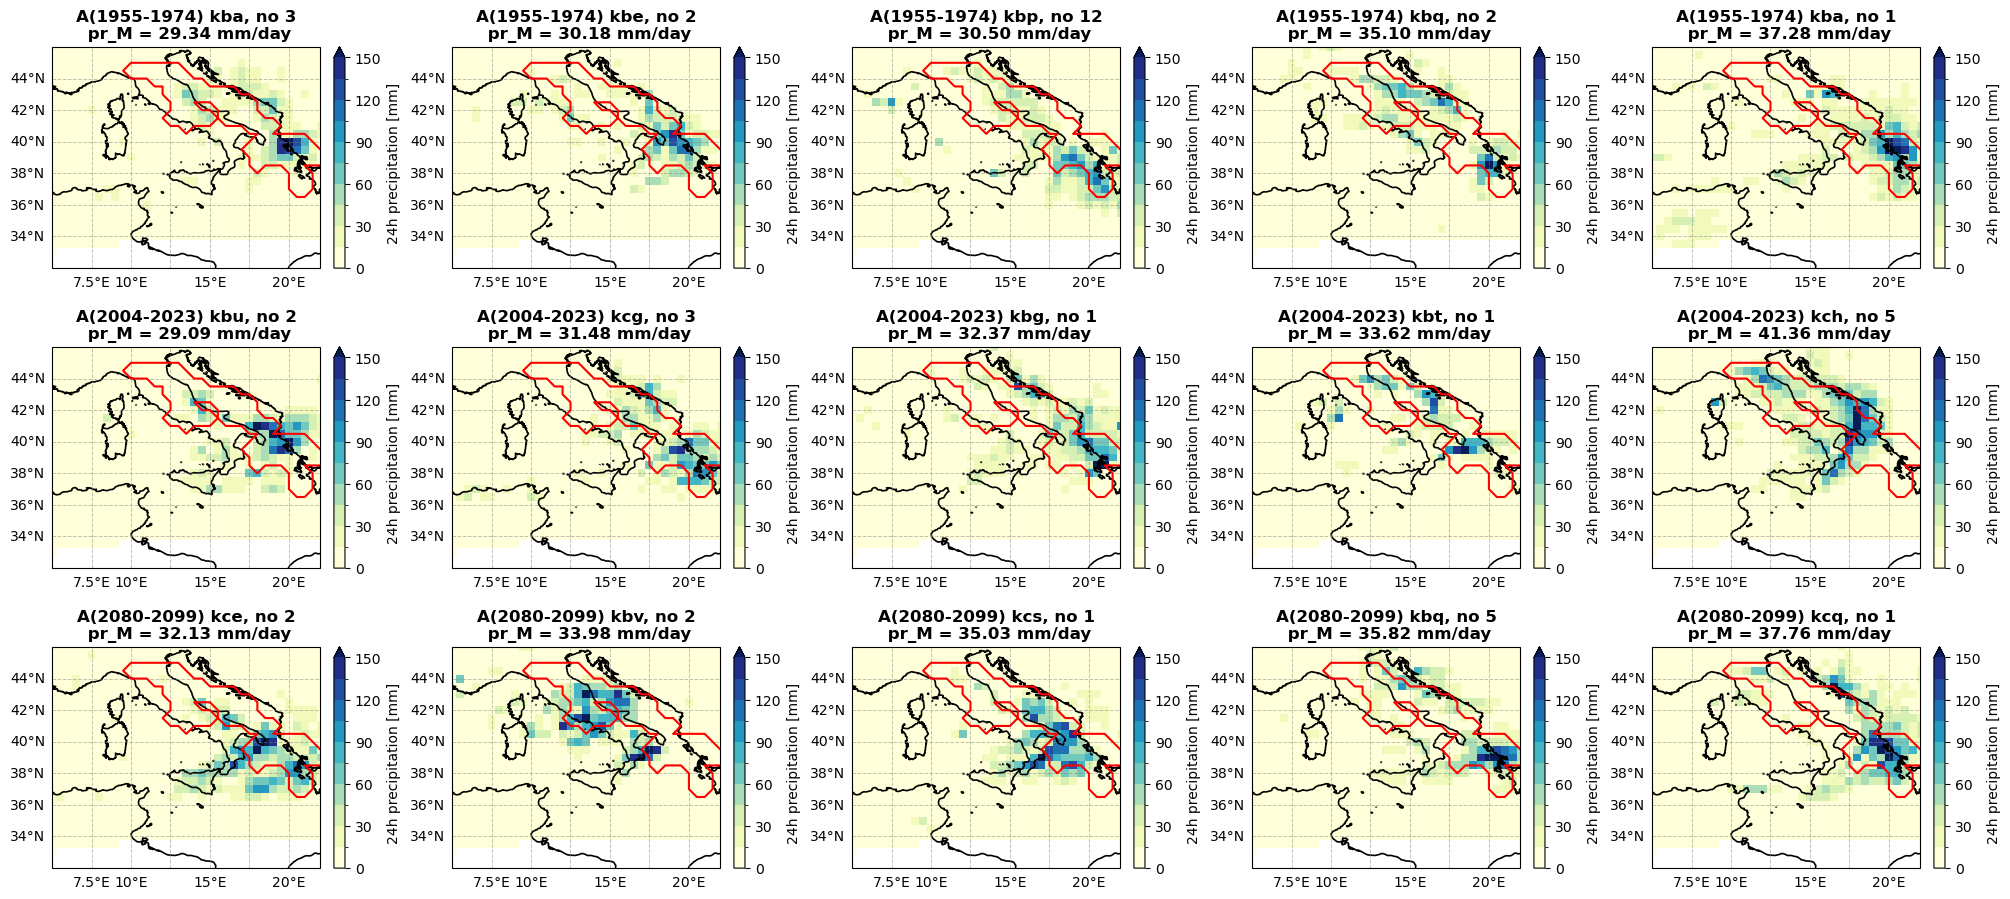

In [64]:
fig, ax = plt.subplots(
    nrows=no_epochs, ncols=N_max, figsize=(4*N_max, 3*no_epochs),
    sharey=True,
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
    )
ax = ax.ravel()

# masks
pr_mask = xr.open_dataset(f'./analogue_data/BAM_data/pr-mask_BAM-psl_{str_event_BAM}_{str_months_BAM}_2004-2023_CRCM5-LE_49membs.nc')['pr_mask']
lon = pr_mask.lon.values
lat = pr_mask.lat.values
land_mask = fanPM.create_land_mask(lon, lat).astype(int)
pr_mask_onland = pr_mask * land_mask
# weights for area average
weights = np.cos(np.deg2rad(pr_mask.lat))
weights_2d = weights.broadcast_like(pr_mask)

# Plot
pr_levels = np.arange(0, 160, 15)
list_averages = []
for j in range(no_epochs):
    year_range = list_year_ranges[j]
    str_year_range = "-".join(str(x) for x in year_range)
    for i in range(N_max):
        # compute precipitation value
        pr_reg = list_pr_max[j][i]
        pr_masked = pr_reg.where(pr_mask > 0)
        box_area_avg = (pr_masked * weights_2d).sum(dim=['lat', 'lon']) / (pr_masked.notnull() * weights_2d).sum(dim=['lat', 'lon'])
        list_averages.append(box_area_avg.values)
        # Plot
        k = j*N_max + i
        value = list_dict_max[j]['values'][i] * factor
        member = list_dict_max[j]['members'][i]
        index = list_dict_max[j]['indices'][i]
        time = list_dict_max[j]['times'][i]
        # Plot precipitation
        fanPM.plot_precipitation(
            ax[k], 
            box_event, 
            list_pr_max[j][i], 
            pr_levels,
            f'A({str_year_range}) {member}, no {index+1}\n pr_M = {value:.2f} mm/day')
        # hatch region mask
        ax[k].contour(
            pr_mask.lon, pr_mask.lat, pr_mask, 
            levels=[0], colors='red', linewidths=1.5, transform=ccrs.PlateCarree(), corner_mask=False
        )
fig.savefig(f'{fig_dir}pr-{N_max}max_analogues-{var_analogues}_{str_event_BAM}_{int(qtl_LE*100)}pct_all-epochs_CRCM5-LE_'+str(no_membs)+'membs.png')
print(list_averages)

### Plot total and epoch-difference in "ensemble-mean of maximum precipitation across analogues" 

For each ensemble member, we compute the grid-point maximum precipitation across analogues.
Then we take the ensemble mean over the above.

In [49]:
# Variable
varname = 'pr'
factor = 3600

# List epochs
list_year_ranges = [[1955, 1974], [2004, 2023], [2080, 2099]] # past [1955-1974], present [2004-2023], near-future [2030-2049], far future [2080-2099]
no_epochs = len(list_year_ranges)

# Difference between epochs
list_diff_indices = [[0,1],[1,2], [0,2]]  # Define the indices of epochs to compare

In [50]:
# Upload analogue data
list_ds = []  # List to store absolute datasets
for i in range(no_epochs):
    year_range = list_year_ranges[i]
    str_year_range = "-".join(str(x) for x in year_range)
    suffix_file = f"ensmean-{varname}max_{str_event_BAM}_{int(100*qtl_LE)}pct_{str_year_range}_CRCM5_{no_membs}membs.nc"
        
    # Load analogue values
    file = f'{diff_dir}analogues-{var_analogues}_{suffix_file}'
    if not os.path.exists(file):
        print(f'File {file} does not exist. Skipping epoch {i+1}.')
        continue
    ds = xr.open_dataset(file)
    list_ds.append(ds)

# upload analogue differences and significance
list_str_diff = []  # List to store string representations of differences
list_ds_diff = []  # List to store difference datasets
list_ds_ks_stats = []  # List to store KS statistics datasets
for i in range(len(list_diff_indices)):
    year_range1 = list_year_ranges[list_diff_indices[i][0]]
    str_year_range1 = "-".join(str(x) for x in year_range1)
    year_range2 = list_year_ranges[list_diff_indices[i][1]]
    str_year_range2 = "-".join(str(x) for x in year_range2)
    list_str_diff.append(f'{str_year_range2} - {str_year_range1}')  # Store the string representation of the difference
    suffix_file = f"_ensmean-{varname}max_{str_event_BAM}_{int(100*qtl_LE)}pct_diff{str_year_range2}_{str_year_range1}_CRCM5_{no_membs}membs.nc"

    file_diff = f'{diff_dir}analogues-{var_analogues}_difference{suffix_file}'
    if not os.path.exists(file_diff):
        print(f'File {file_diff} does not exist. Skipping epoch {i+1}.')
        continue
    ds = xr.open_dataset(file_diff)
    list_ds_diff.append(ds)

    file_ks = f'{diff_dir}analogues-{var_analogues}_KS-statistics{suffix_file}'
    if not os.path.exists(file_ks):
        print(f'File {file_ks} does not exist. Skipping epoch {i+1}.')
        continue
    ds = xr.open_dataset(file_ks)
    list_ds_ks_stats.append(ds)

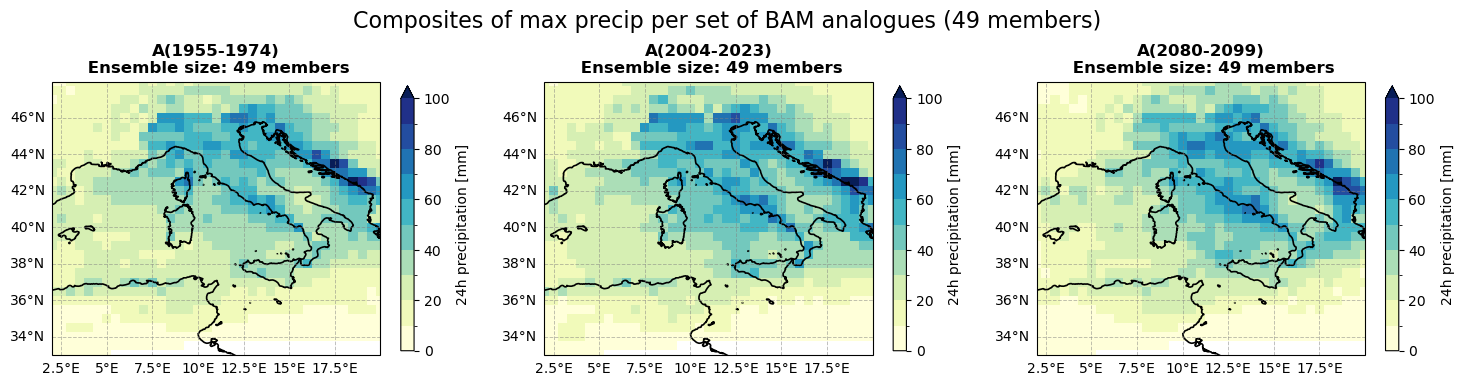

In [51]:
fig, ax = plt.subplots(
    nrows=1, ncols=no_epochs, figsize=(6*no_epochs, 4.3),
    sharey=True,
    subplot_kw={'projection': ccrs.PlateCarree()}
    )
ax = ax.ravel()

# levels
if no_node == 1 and no_event == 1:
    levels = np.arange(0, 210, 20)
elif no_node == 5 and no_event == 4:
    levels = np.arange(0, 110, 10)
elif no_node == 5 and no_event == 23:
    levels = np.arange(0, 110, 10)
elif no_node == 3 and no_event == 3:
    levels = np.arange(0, 210, 20)

# Plot
for i in range(no_epochs):
    fanPM.plot_precipitation(
        ax[i], 
        box_event, 
        list_ds[i][varname]*factor, 
        levels,
        f'A({list_year_ranges[i][0]}-{list_year_ranges[i][1]})\n Ensemble size: {no_membs} members')
fig.suptitle(f'Composites of max precip per set of BAM analogues ({no_membs} members)', fontsize=16)

# Save the figure
fig.savefig(f"{fig_dir}ensmean-{varname}max_analogues-{var_analogues}_{str_event_BAM}_{int(qtl_LE*100)}pct_CRCM5_{no_membs}membs.png", bbox_inches='tight', dpi=300)

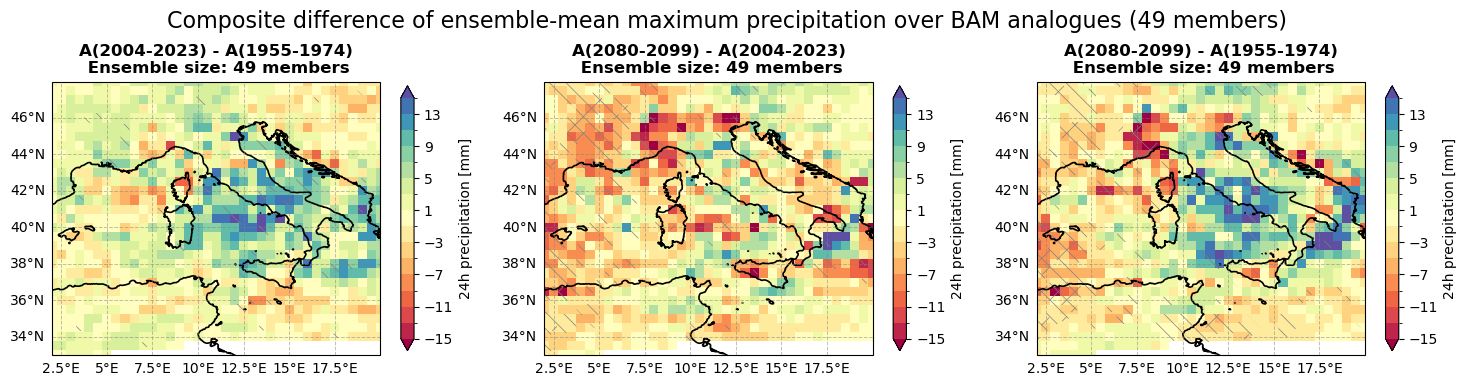

In [52]:
fig, ax = plt.subplots(
    nrows=1, ncols=no_epochs, figsize=(6*no_epochs, 4.3),
    sharey=True,
    subplot_kw={'projection': ccrs.PlateCarree()}
    )
ax = ax.ravel()

# Plot
for i in range(len(list_diff_indices)):
    # Plot the difference for each ensemble size and epoch difference
    ds_diff = list_ds_diff[i]
    ds_ks_stats = list_ds_ks_stats[i]
    p_values = ds_ks_stats.sel(output='pvalue').squeeze()[varname].values
    str_year_range1 = f"{list_year_ranges[list_diff_indices[i][0]][0]}-{list_year_ranges[list_diff_indices[i][0]][1]}"
    str_year_range2 = f"{list_year_ranges[list_diff_indices[i][1]][0]}-{list_year_ranges[list_diff_indices[i][1]][1]}"
    subtitle = f'A({str_year_range2}) - A({str_year_range1})\n Ensemble size: {no_membs} members'
    fanPM.plot_precipitation(
        ax[i], box_event, ds_diff['pr']*factor, 
        precip_levels=np.arange(-15, 16, 2), title=subtitle
        )
    # 
    # Flatten while ignoring NaNs
    mask = ~np.isnan(p_values)
    pvals_flat = p_values[mask]
    # Apply FDR correction
    rejected, pvals_corrected = fdrcorrection(pvals_flat, alpha=0.05)
    # Put results back into 2D arrays, filling NaNs where appropriate
    rejected_2d = np.full(p_values.shape, np.nan)
    rejected_2d[mask] = rejected
    pvals_corrected_2d = np.full(p_values.shape, np.nan)
    pvals_corrected_2d[mask] = pvals_corrected
    # Hatching where significant
    significant_mask_corrected = pvals_corrected_2d < 0.05
    significant_mask = p_values < 0.05
    # Contour significant areas
    plt.rcParams['hatch.linewidth'] = 0.5   # thinner lines
    plt.rcParams['hatch.color'] = 'grey'
    ax[i].contourf(
        ds_diff['lon'], ds_diff['lat'], significant_mask_corrected,
        levels=[0.5, 1.5], 
        colors='none',      # no fill color
        hatches=['//'],
        transform=ccrs.PlateCarree()
    )
    ax[i].contourf(
        ds_diff['lon'], ds_diff['lat'], significant_mask,
        levels=[0.5, 1.5], 
        colors='none',      # no fill color
        hatches=['\\\\'],
        transform=ccrs.PlateCarree()
    )

fig.suptitle(f'Composite difference of ensemble-mean maximum precipitation over BAM analogues ({no_membs} members)', fontsize=16)

# Save the figure
fig.savefig(f"{fig_dir}ensmean-{varname}max_analogue-differences-{var_analogues}_{str_event_BAM}_{int(qtl_LE*100)}pct_CRCM5_{no_membs}membs.png", bbox_inches='tight', dpi=300)